<a href="https://colab.research.google.com/github/Sythaz/tomalyze/blob/main/Collab/PBL_Gabungan_Seg_Enh_Ekst_SVM_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🍅 **Klasifikasi Tingkat Kematangan Tomat** 🍅

# **Segmentasi**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


========== RIPE ==========
[SAVED] 25/100
[SAVED] 50/100
[SAVED] 75/100
[SAVED] 100/100

=== VISUALISASI 3 GAMBAR RIPE ===


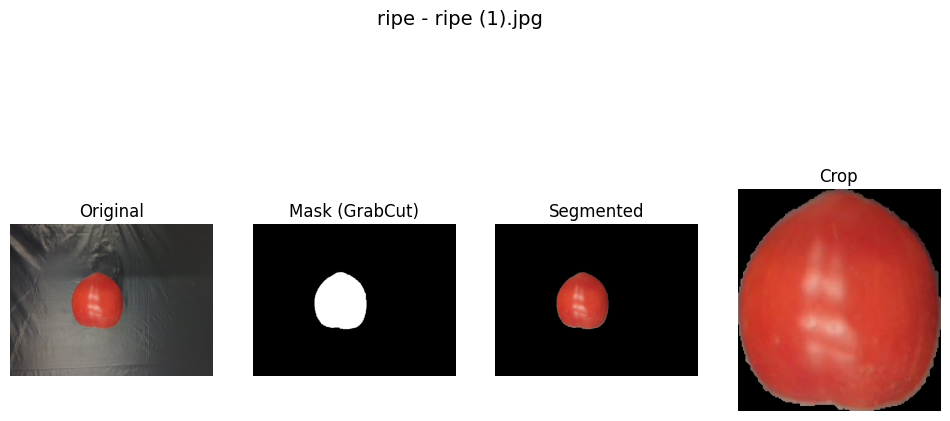

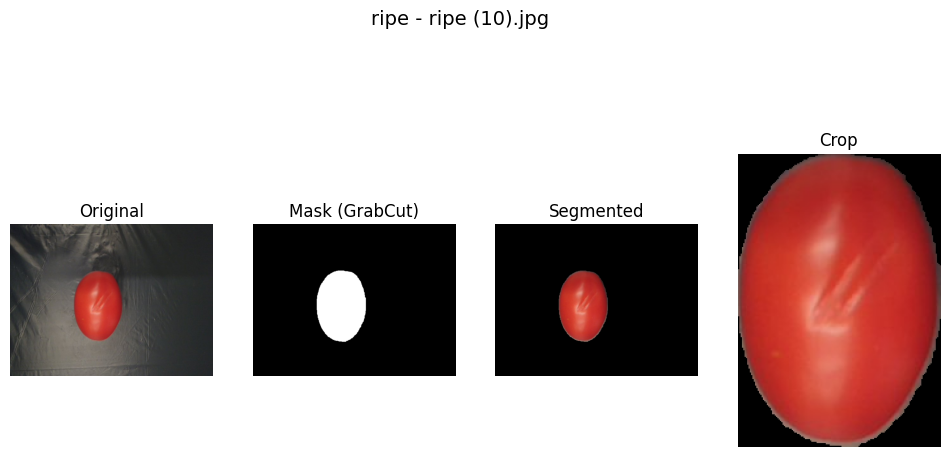

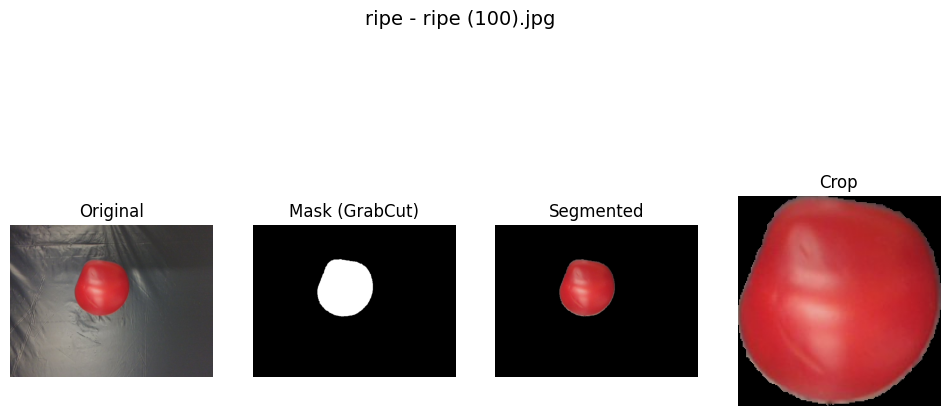


========== HALF-RIPE ==========
[SAVED] 25/100
[SAVED] 50/100
[SAVED] 75/100
[SAVED] 100/100

=== VISUALISASI 3 GAMBAR HALF-RIPE ===


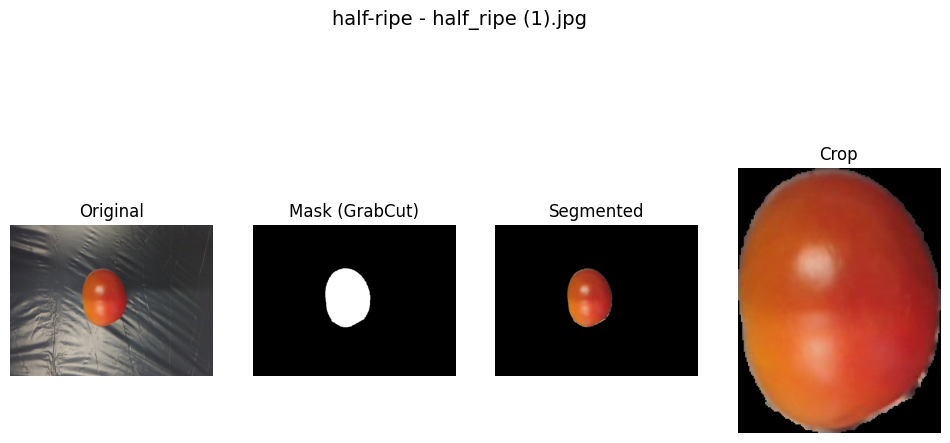

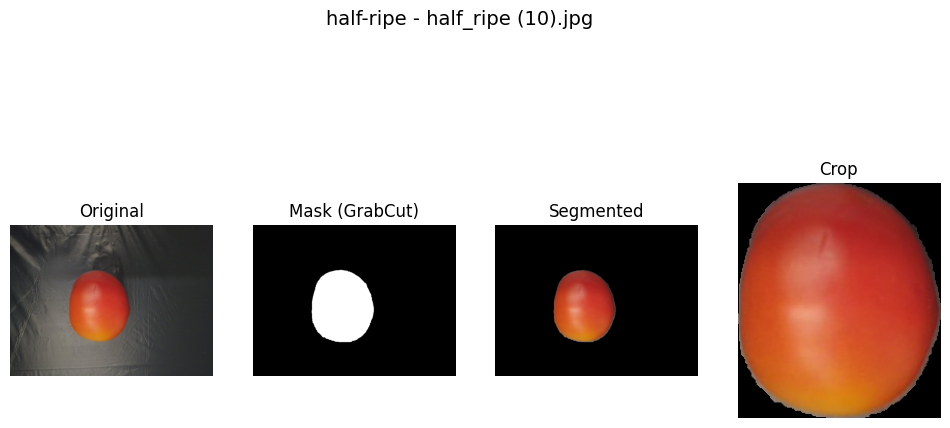

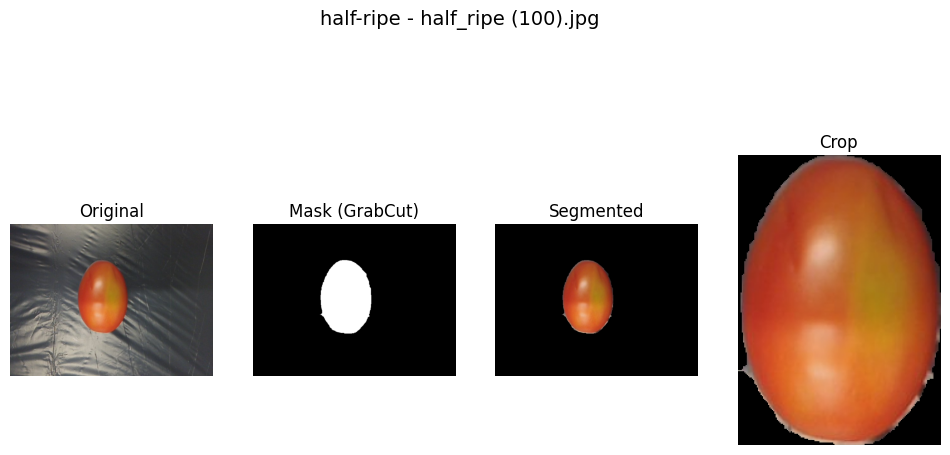


========== UNRIPE ==========
[SAVED] 25/100
[SAVED] 50/100
[SAVED] 75/100
[SAVED] 100/100

=== VISUALISASI 3 GAMBAR UNRIPE ===


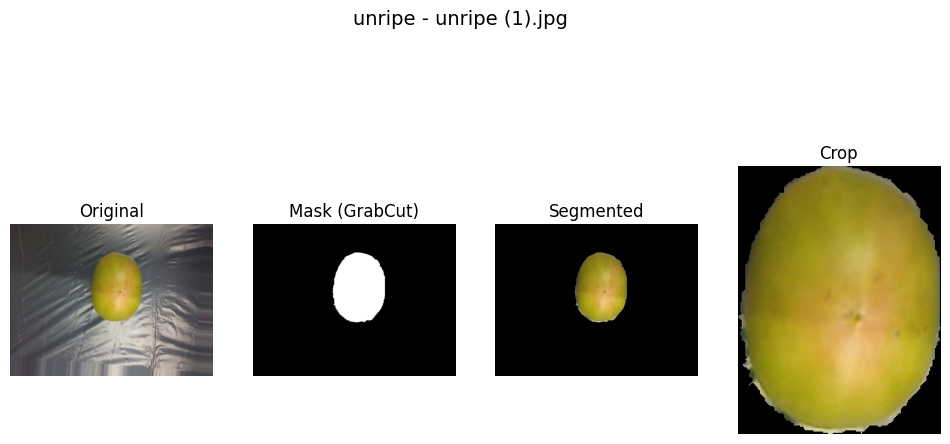

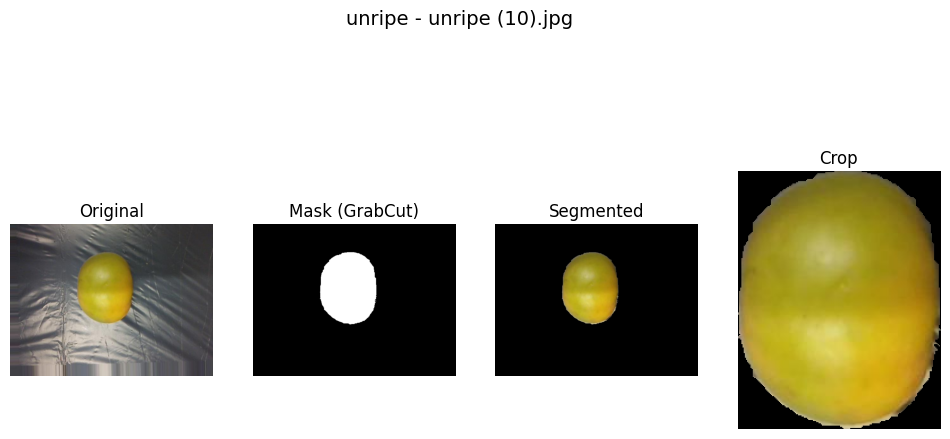

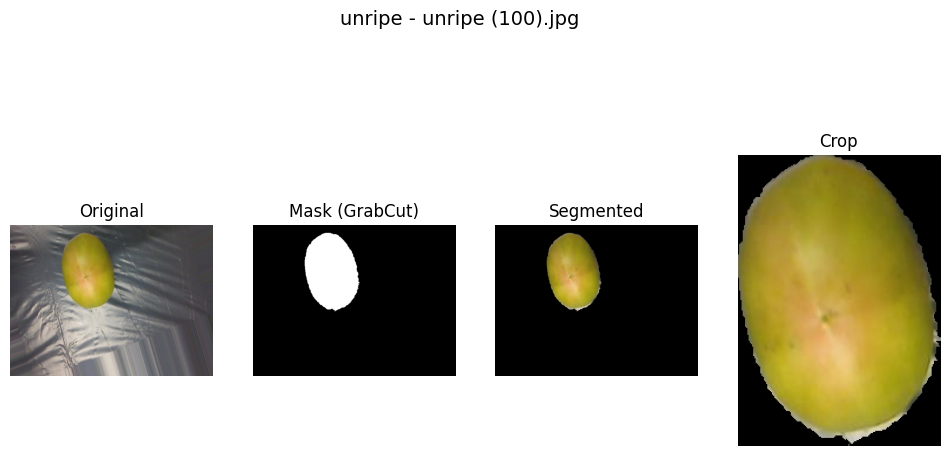

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

def auto_segment_grabcut(img_bgr):

    # --- A. INITIAL BOUNDING BOX ---
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    lower = np.array([0, 40, 50])
    upper = np.array([180, 255, 255])
    mask_rough = cv2.inRange(hsv, lower, upper)

    contours, _ = cv2.findContours(mask_rough, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None, None, None, None

    c = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(c)

    # Padding biar tomat tidak kegunting
    pad = 10
    h_img, w_img = img_bgr.shape[:2]
    x = max(0, x - pad); y = max(0, y - pad)
    w = min(w_img - x, w + 2*pad); h = min(h_img - y, h + 2*pad)
    rect = (x, y, w, h)

    # --- B. GRABCUT ---
    mask = np.zeros(img_bgr.shape[:2], np.uint8)
    bgdModel = np.zeros((1, 65), np.float64)
    fgdModel = np.zeros((1, 65), np.float64)

    cv2.grabCut(img_bgr, mask, rect, bgdModel, fgdModel, 5, cv2.GC_INIT_WITH_RECT)

    # Mask final GrabCut
    mask_final = np.where((mask == 0) | (mask == 2), 0, 1).astype('uint8')
    mask_final = mask_final * 255

    # --- Hasil segmentasi (gabungan/filter final) ---
    segmented = cv2.bitwise_and(img_bgr, img_bgr, mask=mask_final)

    # --- Cari area non-zero dari mask untuk bounding box ---
    coords = cv2.findNonZero(mask_final)

    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)

        # Crop dari gambar hasil segmentasi
        crop_img = segmented[y:y+h, x:x+w]
    else:
        crop_img = None
        crop_mask = None

    return img_bgr, mask_final, segmented, crop_img


def show_results(ori, mask, seg, crop, title):
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 4, 1)
    plt.imshow(cv2.cvtColor(ori, cv2.COLOR_BGR2RGB))
    plt.title("Original"); plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(mask, cmap='gray')
    plt.title("Mask (GrabCut)"); plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(cv2.cvtColor(seg, cv2.COLOR_BGR2RGB))
    plt.title("Segmented"); plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
    plt.title("Crop"); plt.axis("off")

    plt.suptitle(title, fontsize=14)
    plt.show()


dataset_paths = {
    "ripe": "/content/drive/MyDrive/PCVK/datasetPBL/ripe",
    "half-ripe": "/content/drive/MyDrive/PCVK/datasetPBL/half-ripe",
    "unripe": "/content/drive/MyDrive/PCVK/datasetPBL/unripe"
}

for label, path in dataset_paths.items():
    print(f"\n========== {label.upper()} ==========")

    files = sorted(os.listdir(path))
    vis_files = files[:3]  # ambil 3 gambar teratas
    total_files = len(files)
    counter = 0

    for fname in files:
        img_path = os.path.join(path, fname)
        img = cv2.imread(img_path)

        ori, mask, seg, crop = auto_segment_grabcut(img)

        if ori is None or crop is None:
            print(f"[SKIPPED] {fname} - objek tidak terdeteksi atau crop kosong")
            continue

        # Simpan SEMUA HASIL segmentasi
        save_root = "/content/drive/MyDrive/PCVK/datasetPBL/output-segmentation"
        os.makedirs(os.path.join(save_root, label, "seg"), exist_ok=True)

        base, ext = os.path.splitext(fname)
        save_path = os.path.join(save_root, label, "seg", f"{base}_seg.png")
        cv2.imwrite(save_path, crop)

        # Hitung jumlah tersimpan
        counter += 1
        if counter % 25 == 0:
            print(f"[SAVED] {counter}/{total_files}")

    # VISUALISASI 3 GAMBAR PERTAMA
    print(f"\n=== VISUALISASI 3 GAMBAR {label.upper()} ===")
    for fname in vis_files:
        img_path = os.path.join(path, fname)
        img = cv2.imread(img_path)

        ori, mask, seg, crop = auto_segment_grabcut(img)

        if ori is None:
            continue

        show_results(ori, mask, seg, crop, f"{label} - {fname}")

# **Enhancement**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📂 Input: /content/drive/MyDrive/PCVK/datasetPBL/output-segmentation
📂 Output: /content/drive/MyDrive/PCVK/datasetPBL/Dataset_Enhanced
✅ Path siap.

🚀 Processing: RIPE (100 files)


100%|██████████| 100/100 [00:42<00:00,  2.35it/s]



🚀 Processing: HALF-RIPE (100 files)


100%|██████████| 100/100 [00:40<00:00,  2.46it/s]



🚀 Processing: UNRIPE (100 files)


100%|██████████| 100/100 [00:41<00:00,  2.43it/s]



✅ Selesai! Total 300 gambar tersimpan di: /content/drive/MyDrive/PCVK/datasetPBL/Dataset_Enhanced

📊 NILAI PSNR: 34.12 dB


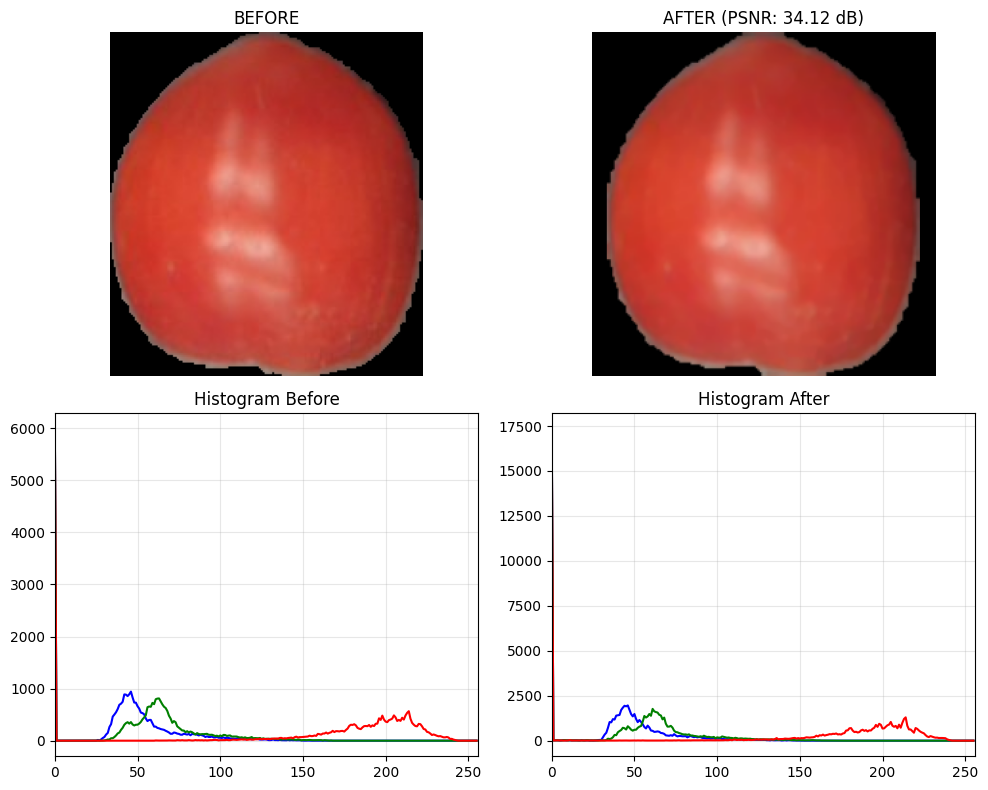

In [ ]:
# ==========================================
# TAHAP 2: IMAGE ENHANCEMENT & PREPROCESSING
# ==========================================

import os
import cv2
import glob
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
from tqdm import tqdm

# --- 1. SETUP & KONFIGURASI ---
drive.mount('/content/drive')

# PASTE PATH FOLDER DI SINI
INPUT_PATH = '/content/drive/MyDrive/PCVK/datasetPBL/output-segmentation'
OUTPUT_PATH = '/content/drive/MyDrive/PCVK/datasetPBL/Dataset_Enhanced'

print(f"📂 Input: {INPUT_PATH}")
print(f"📂 Output: {OUTPUT_PATH}")

if not os.path.exists(INPUT_PATH):
    print("❌ Path Input tidak ditemukan! Cek kembali path Google Drive.")
else:
    print("✅ Path siap.")

# --- 2. FUNGSI UTAMA: PREPROCESSING ---
def preprocess_image(img):
    if img is None: return None

    # A. Denoising (Median Blur)
    denoised = cv2.medianBlur(img, 3)

    # B. Morphological Closing (Menutup lubang kecil)
    kernel = np.ones((3,3), np.uint8)
    closing = cv2.morphologyEx(denoised, cv2.MORPH_CLOSE, kernel)

    # C. Smart Resize (Padding) - Agar gambar tidak gepeng
    old_h, old_w = closing.shape[:2]
    target_size = 256

    # Hitung rasio
    ratio = min(target_size / old_h, target_size / old_w)
    new_h, new_w = int(old_h * ratio), int(old_w * ratio)

    # Resize proporsional
    resized = cv2.resize(closing, (new_w, new_h))

    # Tempel ke kanvas hitam 256x256
    final_img = np.zeros((target_size, target_size, 3), dtype=np.uint8)
    y_offset = (target_size - new_h) // 2
    x_offset = (target_size - new_w) // 2
    final_img[y_offset:y_offset+new_h, x_offset:x_offset+new_w] = resized

    return final_img

# --- 3. EKSEKUSI BATCH (SEMUA FOLDER) ---
def process_dataset(input_root, output_root):
    categories = ['ripe', 'half-ripe', 'unripe']
    total_success = 0

    for category in categories:
        path_in = os.path.join(input_root, category, 'seg')
        path_out = os.path.join(output_root, category)

        if not os.path.exists(path_in):
            print(f"⚠️ Folder tidak ditemukan: {path_in}")
            continue

        if not os.path.exists(path_out):
            os.makedirs(path_out)

        files = glob.glob(os.path.join(path_in, "*.png"))
        print(f"\n🚀 Processing: {category.upper()} ({len(files)} files)")

        for file_path in tqdm(files):
            try:
                img = cv2.imread(file_path)
                processed_img = preprocess_image(img)

                if processed_img is not None:
                    filename = os.path.basename(file_path)
                    cv2.imwrite(os.path.join(path_out, filename), processed_img)
                    total_success += 1
            except Exception as e:
                print(f"Error: {e}")

    print(f"\n✅ Selesai! Total {total_success} gambar tersimpan di: {output_root}")

# Jalankan Proses
process_dataset(INPUT_PATH, OUTPUT_PATH)

# --- 4. ANALISIS PSNR & HISTOGRAM (UNTUK LAPORAN) ---
def calculate_psnr(img1, img2):
    # Resize img1 agar dimensi sama untuk perhitungan
    if img1.shape != img2.shape:
        img1 = cv2.resize(img1, (img2.shape[1], img2.shape[0]))

    mse = np.mean((img1 - img2) ** 2)
    if mse == 0: return 100
    return 20 * math.log10(255.0 / math.sqrt(mse))

def plot_histogram(img, title, ax):
    colors = ('b', 'g', 'r')
    for i, color in enumerate(colors):
        hist = cv2.calcHist([img], [i], None, [256], [0, 256])
        ax.plot(hist, color=color)
    ax.set_title(title)
    ax.set_xlim([0, 256])
    ax.grid(True, alpha=0.3)

def analyze_enhancement(input_path, output_path):
    img_before = cv2.imread(input_path)
    img_after = cv2.imread(output_path)

    if img_before is None or img_after is None:
        print("❌ File untuk analisis tidak ditemukan.")
        return

    score_psnr = calculate_psnr(img_before, img_after)
    print(f"\n📊 NILAI PSNR: {score_psnr:.2f} dB")

    # Visualisasi
    fig, axs = plt.subplots(2, 2, figsize=(10, 8))

    axs[0, 0].imshow(cv2.cvtColor(img_before, cv2.COLOR_BGR2RGB))
    axs[0, 0].set_title("BEFORE")
    axs[0, 0].axis('off')

    axs[0, 1].imshow(cv2.cvtColor(img_after, cv2.COLOR_BGR2RGB))
    axs[0, 1].set_title(f"AFTER (PSNR: {score_psnr:.2f} dB)")
    axs[0, 1].axis('off')

    plot_histogram(img_before, "Histogram Before", axs[1, 0])
    plot_histogram(img_after, "Histogram After", axs[1, 1])

    plt.tight_layout()
    plt.show()

# --- CONTOH PENGGUNAAN ANALISIS ---
# Pastikan nama file di bawah ini ADA di dalam folder
sample_in = os.path.join(INPUT_PATH, 'ripe/seg/ripe (1)_seg.png')
sample_out = os.path.join(OUTPUT_PATH, 'ripe/ripe (1)_seg.png')

analyze_enhancement(sample_in, sample_out)

# **Ekstraksi Fitur**

## **Penjelasan**



```
# Ini diformat sebagai kode
```

### **Kelompok Fitur yang Digunakan:**

### **1. Circular Hue Features (3 Fitur)**

Dipakai untuk merepresentasikan warna dasar tomat (Hue) dalam bentuk matematis yang benar.
Kenapa circular?

Karena Hue bukan angka biasa: 0° (merah) sangat dekat dengan 360° (merah lagi), bukan jauh.

Jadi jika kita tidak perlakukan Hue sebagai “data melingkar”, analisis warna akan salah total.

#### **• mean_cos_H**

Mengubah Hue (warna) menjadi koordinat **sumbu X** pada lingkaran warna.

Interpretasi:

* Nilai mendekati **+1** → warna dominan merah → tomat matang (ripe).
* Nilai mendekati **–1** → warna dominan kehijauan → tomat mentah (unripe).

Ini adalah **pembeda matang vs mentah paling kuat**.

#### **• mean_sin_H**

Komponen **sumbu Y** pada lingkaran warna.

Kenapa perlu?
Agar lokasi warna tomat lebih presisi.
Kalau mean_cos_H mengukur “merah vs hijau”, mean_sin_H mengukur “kuning vs biru”.

Fungsinya:

* Membedakan **kuning/oranye** (half-ripe) dari merah/hijau.

#### **• circ_std_H**

Circular standard deviation = *keragaman warna*.

Interpretasi:

* **Nilai rendah** → warna kulit tomat seragam (merah penuh atau hijau penuh).
* **Nilai tinggi** → warna bercampur (merah + hijau + kuning bersamaan).

Ini cocok untuk mendeteksi **tomat half-ripe**, karena tingkat kematangannya memang tidak seragam.

---

### **2. Fitur Saturation (HSV – Komponen S: 1 Fitur)**

Warna tomat bisa merah pekat, merah kusam, atau hijau cerah, dan semua itu tercermin lewat Saturation.

#### **• mean_S**

Mengukur seberapa “kuat” warna tomat.

Interpretasi:

* **Unripe (hijau)**: warna sangat solid → saturasi tinggi.
* **Half-ripe**: warna mulai bercampur → saturasi sedang.
* **Ripe**: kadang warnanya terlihat lebih lembut/matte karena banyak highlight cahaya → saturasi sedikit menurun.

Fitur ini membantu membedakan **solid green → yellow → red progression**.

---

### **3. LAB Color Feature (Persepsi warna ala manusia, 1 Fitur)**

Ruang warna LAB dirancang agar perubahannya mendekati cara manusia melihat warna.

#### **• mean_a**

Komponen **a*** menyatakan pergeseran warna:

* Nilai negatif = hijau
* Nilai positif = merah

Keunggulan besar mean_a:

* **Stabil terhadap perubahan pencahayaan** (tidak seperti RGB)
* Konsisten menunjukkan tingkat kemerahan tomat

Interpretasi:

* **Unripe** → nilai a* rendah / negatif
* **Half-ripe** → mulai naik
* **Ripe** → a* tinggi

Fitur ini sering menjadi **fitur paling kuat** untuk menentukan kematangan.

---

### **4. RGB Color Indices (Bukan Raw RGB: 4 Fitur)**

Kenapa tidak pakai RGB mentah?

Karena RGB sangat sensitif terhadap:

* gelap-terang ruangan
* shadow
* highlight
* kamera

Jadi kita pakai bentuk *rasio*, bukan nilai mentah.

#### **• norm_R**

R / (R + G + B) → persentase merah terhadap seluruh warna.

Kelebihannya:

* Hilangkan efek gelap—tomat merah di tempat gelap tetap terlihat “merah dominan” (rasio tetap tinggi).
* Pembeda matang vs mentah yang sangat stabil.

#### **• rg_ratio**

(R – G) / (R + G)

Ini indikator paling langsung “merah vs hijau”.

Interpretasi:

* Nilai negatif → kehijauan → unripe
* Nol → seimbang → half-ripe (kuning/oranye)
* Nilai positif → kemerahan kuat → ripe

#### **• mean_R**

Rata-rata nilai kanal merah.
Menggambarkan kemunculan **likopen** (pigmen merah saat pematangan).

* Ripe → tinggi
* Half-ripe → sedang
* Unripe → rendah

#### **• mean_G**

Rata-rata kanal hijau.
Menggambarkan **sisa klorofil**.

* Unripe → tinggi
* Half-ripe → menurun
* Ripe → rendah

Mean_R dan mean_G ini bukan fitur utama, tapi tetap berguna untuk mendukung pola dasar perubahan warna.

---

## **Kesimpulan:**

Karena masing-masing kelompok fitur menangkap **bagian berbeda dari proses pematangan tomat**:

1. **Circular Hue** → warna dasar dan keragaman warna (ripe vs half-ripe vs unripe).
2. **Saturation** → kekuatan warna, perubahan dari solid green ke matte red.
3. **Lab a*** → indikator merah-hijau yang stabil terhadap pencahayaan.
4. **RGB Indices** → rasio warna yang tahan terhadap efek cahaya.

Fitur-fitur ini dipilih agar:

* tidak bias cahaya
* tidak bias shadow
* bisa membedakan 3 kelas
* stabil dan mudah divisualisasikan
* relevan secara fisiologi warna tomat


## **KODE: KUIS 2**

In [ ]:
import os
import glob
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns

In [ ]:
!pip install mahotas
!pip install ace_tools

In [ ]:
import os
import glob
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------
# FUNGSI UTAMA EKSTRAKSI FITUR (LAB, HSV, RGB)
# ------------------------------------------

def extract_features(img_bgr):
    # Untuk jaga-jaga agar gambar asli tidak termodifikasi maka kita copy
    img_crop = img_bgr.copy()

    # =====================================
    # 1. MASK sederhana yaitu jika semua pixel dianggap valid kecuali pixel yang benar-benar hitam (0,0,0)
    #    gambar: [height[0], width[1], channel rgb[2]]
    #    axis=2 berarti melakukan pengecekan pada bagian channel RGB dari setiap pixel
    #    np.any digunakan untuk mengecek apakah di antara R, G, atau B ada nilai yang bukan 0.
    #    Jika minimal satu channel ada selain 0, maka pixel dianggap bagian tomat (True),
    #    jika semua 0 maka dianggap background hitam (False).
    # =====================================
    mask_bin = np.any(img_crop != 0, axis=2)  # mask_bin nanti dipakai untuk mengabaikan pixel background
    # Nanti menghasilkan R, G, dan B seperti [True, False, True]

    # =====================================
    # 2. Konversi warna ke berbagai ruang warna berdasarkan kelompok fitur tadi
    #    Karena kita butuh 3 ruang warna yang berbeda maka dibutuhkan 3 variabel
    #    Tiap variabel terisi oleh gambar asli yang telah diubah menjadi hsv, rgb, dan lab
    # =====================================
    hsv_crop = cv2.cvtColor(img_crop, cv2.COLOR_BGR2HSV)
    img_rgb  = cv2.cvtColor(img_crop, cv2.COLOR_BGR2RGB) # Gambar asli itu BGR
    img_lab  = cv2.cvtColor(img_crop, cv2.COLOR_BGR2LAB)

    # =====================================
    # 3. Ekstraksi channel
    #    Ambil setiap channel warna (R, G, B, Hue, Saturation, a*) dengan indexing [:,:,i]
    #    dan ubah ke tipe float agar mudah dihitung nantinya
    #    (karena gambar cv2 bertipe uint8 yang terbatas dan operasi seperti mean() butuh float untuk mendukung pecahan)
    # =====================================
    # RGB (OpenCV dan asli: 0-255)
    R = img_rgb[:,:,0].astype(np.float32) # ambil seluruh pixel channel merah saja
    G = img_rgb[:,:,1].astype(np.float32) # ambil seluruh pixel  hijau saja
    B = img_rgb[:,:,2].astype(np.float32) # ambil seluruh pixel biru saja

    # HSV
    # Hue: (OpenCV: 0-180, Asli: 0-360)
    H_deg = hsv_crop[:,:,0].astype(np.float32) * 2.0  # Hue di OpenCV 0..180 sehingga diubah ke 0..360
    # Saturation: (OpenCV: 0-255, Asli: 0-1)
    S = hsv_crop[:,:,1].astype(np.float32) / 255.0    # Normalisasi Saturation ke 0..1

    # LAB a* (OpenCV: 0–255, Asli: -128 sampai 128)
    a = img_lab[:,:,1].astype(np.float32) - 128.0     # a* di OpenCV 0..255 sehingg diubah ke -128..128

    # Perlu dinormalisasi H, S, a* perlu di normalisasi agar menyimpan nilai dengan skala aslinya

    # =====================================
    # 4. Ambil hanya piksel tomat
    #    Variable ekstraksi sebelumnya akan di filter lagi sesuai dengan mask_bin
    #    sehingga hanya mengambil nilai yang true saja
    #    semisal [true, false, true] maka didapatkan 2 nilai saja [i, i].
    #    mask_bin tadi bernilai True pada area tomat dan False pada background hitam.
    # =====================================
    Rm = R[mask_bin]
    Gm = G[mask_bin]
    Bm = B[mask_bin]
    Hm = H_deg[mask_bin]    # [5°, 10°, 350°, 355°]
    Sm = S[mask_bin]
    am = a[mask_bin]

    # =====================================
    # 5. Circular Hue Feature (Hue sebagai data melingkar)
    #    Hue adalah sudut warna 0–360°. Karena sifatnya melingkar,
    #    perhitungan Hue tidak bisa dilakukan dengan mean biasa dan
    #    diperlukan pengubahan menjadi cos serta sin juga untuk melakukan perhitungan circular.
    # =====================================
    # Ubah Hue (Hm) dari derajat ke radian dahulu agar melingkar
    Hm_rad = np.deg2rad(Hm)

    # Representasi Hue pada koordinat kartesian:
    # Data Hue bersifat melingkar, sehingga tidak bisa dirata-ratakan secara langsung.
    # cos(H) digunakan sebagai komponen X (arah merah ↔ cyan),
    mean_cos_H = float(np.cos(Hm_rad).mean()) if Hm.size else 0
    # sin(H) digunakan sebagai komponen Y (arah kuning/hijau ↔ biru/magenta).
    mean_sin_H = float(np.sin(Hm_rad).mean()) if Hm.size else 0
    # Rataan komponen ini digunakan untuk menggambarkan arah warna dominan nantinya
    # Sehingga jika nilai mean_cos_H dan mean_sin_H tinggi artinya tomat mengarah ke unripe atau ripe karena nilai dalam radian konsisten
    # Namun jika nilainya rendah maka tomat itu lebih ke half-ripe karena dalam radian memiliki beragam nilai yang membuat rata-rata menjadi tidak konsisten

    # Hitung panjang vektor resultant dari hasil mean cos dan sin tadi
    # Jika Hue konsisten (warna seragam), panjang vektor mendekati 1.
    # Jika Hue bercampur (warna bervariasi), panjang vektor mendekati 0.
    R_length = np.sqrt(mean_cos_H**2 + mean_sin_H**2)

    # Circular standard deviation (circular variance):
    # Semakin besar circ_std_H → warna semakin tidak seragam (ciri half-ripe).
    # Semakin kecil → warna semakin seragam (ripe atau unripe).
    circ_std_H = 1.0 - R_length


    # =========================================================
    # 6. Mean Saturation (HSV)
    #    Saturation menunjukkan tingkat kepekatan warna.
    #    Semakin tinggi nilai mean_S → warna tomat semakin pekat (ciri tomat matang).
    # =========================================================
    mean_S = float(Sm.mean()) if Sm.size else 0

    # =========================================================
    # 7. Mean a* (LAB)
    #    Channel a* stabil terhadap cahaya:
    #    Nilai negatif → hijau, nilai positif → merah.
    #    Rataan a* sangat efektif untuk membedakan unripe vs ripe.
    # =========================================================
    mean_a = float(am.mean()) if am.size else 0

    # =========================================================
    # 8. Normalized RGB Indices
    # =========================================================
    eps = 1e-6   # mencegah pembagian oleh nol

    # Dominansi warna merah relatif terhadap total intensitas RGB.
    norm_R = float((Rm / (Rm + Gm + Bm + eps)).mean()) if Rm.size else 0

    # Rasio merah terhadap hijau (fitur terkuat membedakan ripe vs unripe).
    rg_ratio = float(((Rm - Gm) / (Rm + Gm + eps)).mean()) if Rm.size else 0

    # Rataan nilai merah dan hijau sebagai indikator tambahan fase kematangan.
    mean_R = float(Rm.mean()) if Rm.size else 0
    mean_G = float(Gm.mean()) if Gm.size else 0

    # =====================================
    # 7. Return fitur
    # =====================================
    return {
        # KELOMPOK 1: CIRCULAR HUE
        "mean_cos_H": mean_cos_H,   # Posisi X (Merah vs Cyan)
        "mean_sin_H": mean_sin_H,   # Posisi Y (Hijau vs Magenta)
        "circ_std_H": circ_std_H,   # Tingkat belang/campuran warna (half-ripe detector)

        # KELOMPOK 2: SATURATION
        "mean_S": mean_S,           # Kepekatan warna

        # KELOMPOK 3: LAB
        "mean_a": mean_a,           # Hijau => Merah (stabil cahaya)

        "norm_R": norm_R,           # Dominansi Merah
        "rg_ratio": rg_ratio,       # Merah lawan Hijau

        # KELOMPOK 4: RGB INDICES
        "mean_R": mean_R,           # Indikator Likopen (pigmen merah)
        "mean_G": mean_G,           # Indikator Klorofil (pigmen hijau)
    }, img_rgb, hsv_crop, mask_bin


DATASET_ENH = "/content/drive/MyDrive/PCVK/datasetPBL/Dataset_Enhanced"

# ------------------------------------------
# EKSTRAKSI FITUR SELURUH DATASET
# ------------------------------------------
all_results = []
all_images_rgb = {}
all_images_hsv = {}
all_masks = {}

for tomato in ["ripe","half-ripe","unripe"]:
    folder = f"{DATASET_ENH}/{tomato}"
    imgs = sorted(glob.glob(f"{folder}/*.png"))

    all_images_rgb[tomato] = []
    all_images_hsv[tomato] = []
    all_masks[tomato] = []

    for p in imgs:
        img = cv2.imread(p)
        feats, img_rgb, img_hsv, mask_bin = extract_features(img)

        feats["filename"] = os.path.basename(p)
        feats["label"] = tomato
        feats["path"] = p

        all_results.append(feats)
        all_images_rgb[tomato].append(img_rgb)
        all_images_hsv[tomato].append(img_hsv)
        all_masks[tomato].append(mask_bin)

print("Ekstraksi selesai. Total fitur:", len(all_results))

Ekstraksi selesai. Total fitur: 300


In [ ]:
# ------------------------------------------
# TABEL FITUR: 40 PERTAMA PER LABEL
# ------------------------------------------
print('Menampilkan contoh fitur 40 per label')

paths_all = []
for tomato in ["ripe","half-ripe","unripe"]:
    folder = f"{DATASET_ENH}/{tomato}"
    imgs = sorted(glob.glob(f"{folder}/*.png"))
    paths_all += imgs[:40]

results_40 = []
for feats in all_results:
    if feats["path"] in paths_all:
        results_40.append(feats)

df = pd.DataFrame(results_40)

if not df.empty:
    ordered_cols = ["filename", "label"] + [c for c in df.columns if c not in ["filename", "label", "path"]]
    df = df[ordered_cols]
    df = df.round(3)

    print("\n=== TABEL FITUR ===")
    print("Semakin terang/kuning, maka data semakin besar\n")
    from IPython.display import display
    display(df.style.background_gradient(cmap="viridis", subset=df.columns[2:]))
else:
    print("Tidak ada fitur yang berhasil diekstraksi.")

Menampilkan contoh fitur 40 per label

=== TABEL FITUR ===
Semakin terang/kuning, maka data semakin besar



,filename,label,mean_cos_H,mean_sin_H,circ_std_H,mean_S,mean_a,norm_R,rg_ratio,mean_R,mean_G
0,ripe (1)_seg.png,ripe,0.994000,0.101000,0.001000,0.701000,47.455000,0.611000,0.475000,189.554000,68.056000
1,ripe (10)_seg.png,ripe,0.996000,0.063000,0.002000,0.722000,49.371000,0.637000,0.526000,184.545000,58.162000
2,ripe (100)_seg.png,ripe,0.999000,-0.013000,0.001000,0.682000,50.506000,0.616000,0.526000,188.443000,59.696000
3,ripe (11)_seg.png,ripe,0.999000,0.006000,0.001000,0.730000,50.568000,0.654000,0.577000,176.491000,47.772000
4,ripe (12)_seg.png,ripe,0.999000,0.015000,0.001000,0.709000,51.942000,0.635000,0.544000,189.482000,56.402000
5,ripe (13)_seg.png,ripe,0.999000,0.021000,0.001000,0.712000,49.583000,0.637000,0.545000,180.154000,54.220000
6,ripe (14)_seg.png,ripe,0.998000,-0.014000,0.002000,0.685000,51.642000,0.616000,0.528000,193.145000,60.357000
7,ripe (15)_seg.png,ripe,0.998000,-0.007000,0.002000,0.688000,50.946000,0.621000,0.531000,190.960000,60.100000
8,ripe (16)_seg.png,ripe,0.997000,0.064000,0.001000,0.713000,48.495000,0.629000,0.515000,182.592000,59.212000
9,ripe (17)_seg.png,ripe,0.998000,0.036000,0.001000,0.715000,50.463000,0.641000,0.544000,185.162000,55.647000



=== RANKING KONTRIBUSI FITUR TERHADAP PC1 ===
mean_a        0.376127
mean_sin_H    0.375661
rg_ratio      0.375358
mean_cos_H    0.372902
mean_G        0.371656
norm_R        0.369683
mean_R        0.323814
mean_S        0.240196
circ_std_H    0.010708
Name: PCA1, dtype: float64


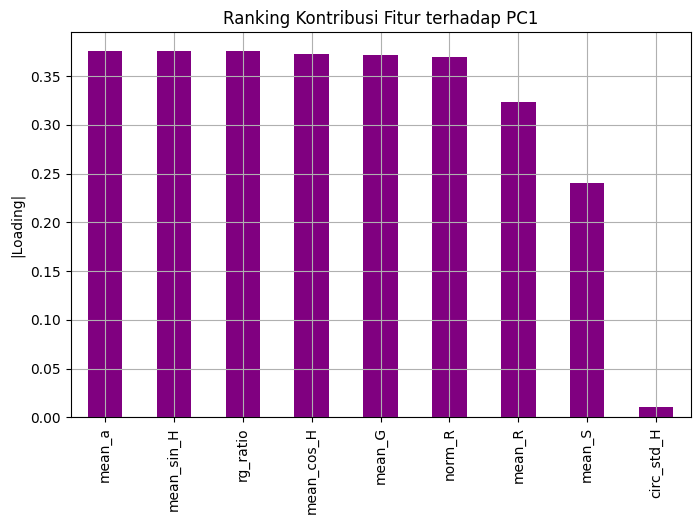

In [ ]:
# ===========================================================
#        PCA + LOADING MATRIX + RANKING KONTRIBUSI PC1
# ===========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ================================
# 1. PILIH FITUR SESUAI DATASET
# ================================
X = df[['mean_cos_H', 'mean_sin_H', 'circ_std_H',
        'mean_S', 'mean_a', 'norm_R', 'rg_ratio',
        'mean_R', 'mean_G']]

# ================================
# 2. SCALING DATA
# ================================
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# ================================
# 3. FIT PCA
# ================================
pca = PCA(n_components=len(X.columns))
pca.fit(X_scaled)

# ================================
# 4. BUAT LOADING MATRIX
# ================================
loading = pd.DataFrame(
    pca.components_.T,
    columns=[f"PCA{i+1}" for i in range(len(pca.components_))],
    index=X_scaled.columns
)

# ================================
# 5. RANKING KONTRIBUSI FITUR KE PC1
# ================================
importance = loading["PCA1"].abs().sort_values(ascending=False)

print("\n=== RANKING KONTRIBUSI FITUR TERHADAP PC1 ===")
print(importance)

# ================================
# 6. PLOTTING
# ================================
plt.figure(figsize=(8,5))
importance.plot(kind="bar", color="purple")
plt.title("Ranking Kontribusi Fitur terhadap PC1")
plt.ylabel("|Loading|")
plt.grid(True)
plt.show()



=== RANKING KONTRIBUSI FITUR TERHADAP PC1 ===
mean_a        0.376127
mean_sin_H    0.375661
rg_ratio      0.375358
mean_cos_H    0.372902
mean_G        0.371656
norm_R        0.369683
mean_R        0.323814
mean_S        0.240196
circ_std_H    0.010708
Name: PCA1, dtype: float64


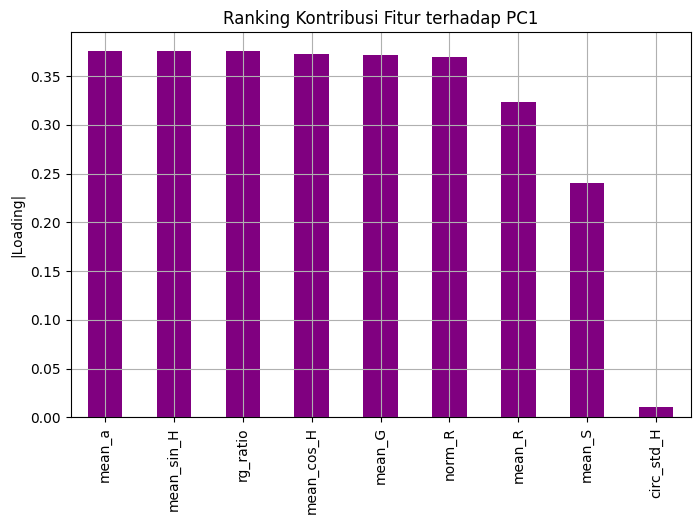

In [ ]:
# ===========================================================
#      RANKING KONTRIBUSI FITUR
# ===========================================================
# Goal:
# Menampilkan fitur mana yang paling berpengaruh terhadap PC1.
# PC1 adalah komponen utama pertama (arah variansi terbesar pada data).
# Loadings PCA menunjukkan seberapa kuat setiap fitur menarik PC1 ke arah tertentu.
# Semakin besar nilai loading (positif atau negatif), semakin besar kontribusinya.
# Oleh karena itu digunakan .abs() (magnitudo) karena tanda + / - hanya arah, bukan kekuatan.

# importance = loading["PCA1"].abs().sort_values(ascending=False)
#   loading["PCA1"] → mengambil kolom PC1 dari loading matrix (nilai kontribusi tiap fitur)
#   .abs()           → mengambil nilai absolut (besar kontribusi, abaikan arah)
#   .sort_values()   → mengurutkan fitur dari kontribusi terbesar ke kecil
importance = loading["PCA1"].abs().sort_values(ascending=False)

print("\n=== RANKING KONTRIBUSI FITUR TERHADAP PC1 ===")
print(importance)

# Plot batang untuk memvisualisasikan fitur mana yang punya kontribusi terbesar.
# Semakin tinggi batang → fitur tersebut paling menjelaskan variansi dataset.
plt.figure(figsize=(8,5))
importance.plot(kind="bar", color="purple")
plt.title("Ranking Kontribusi Fitur terhadap PC1")  # PC1 = variasi terbesar pada seluruh fitur
plt.ylabel("|Loading|")                             # loading = elemen eigenvector PC1
plt.grid(True)
plt.show()

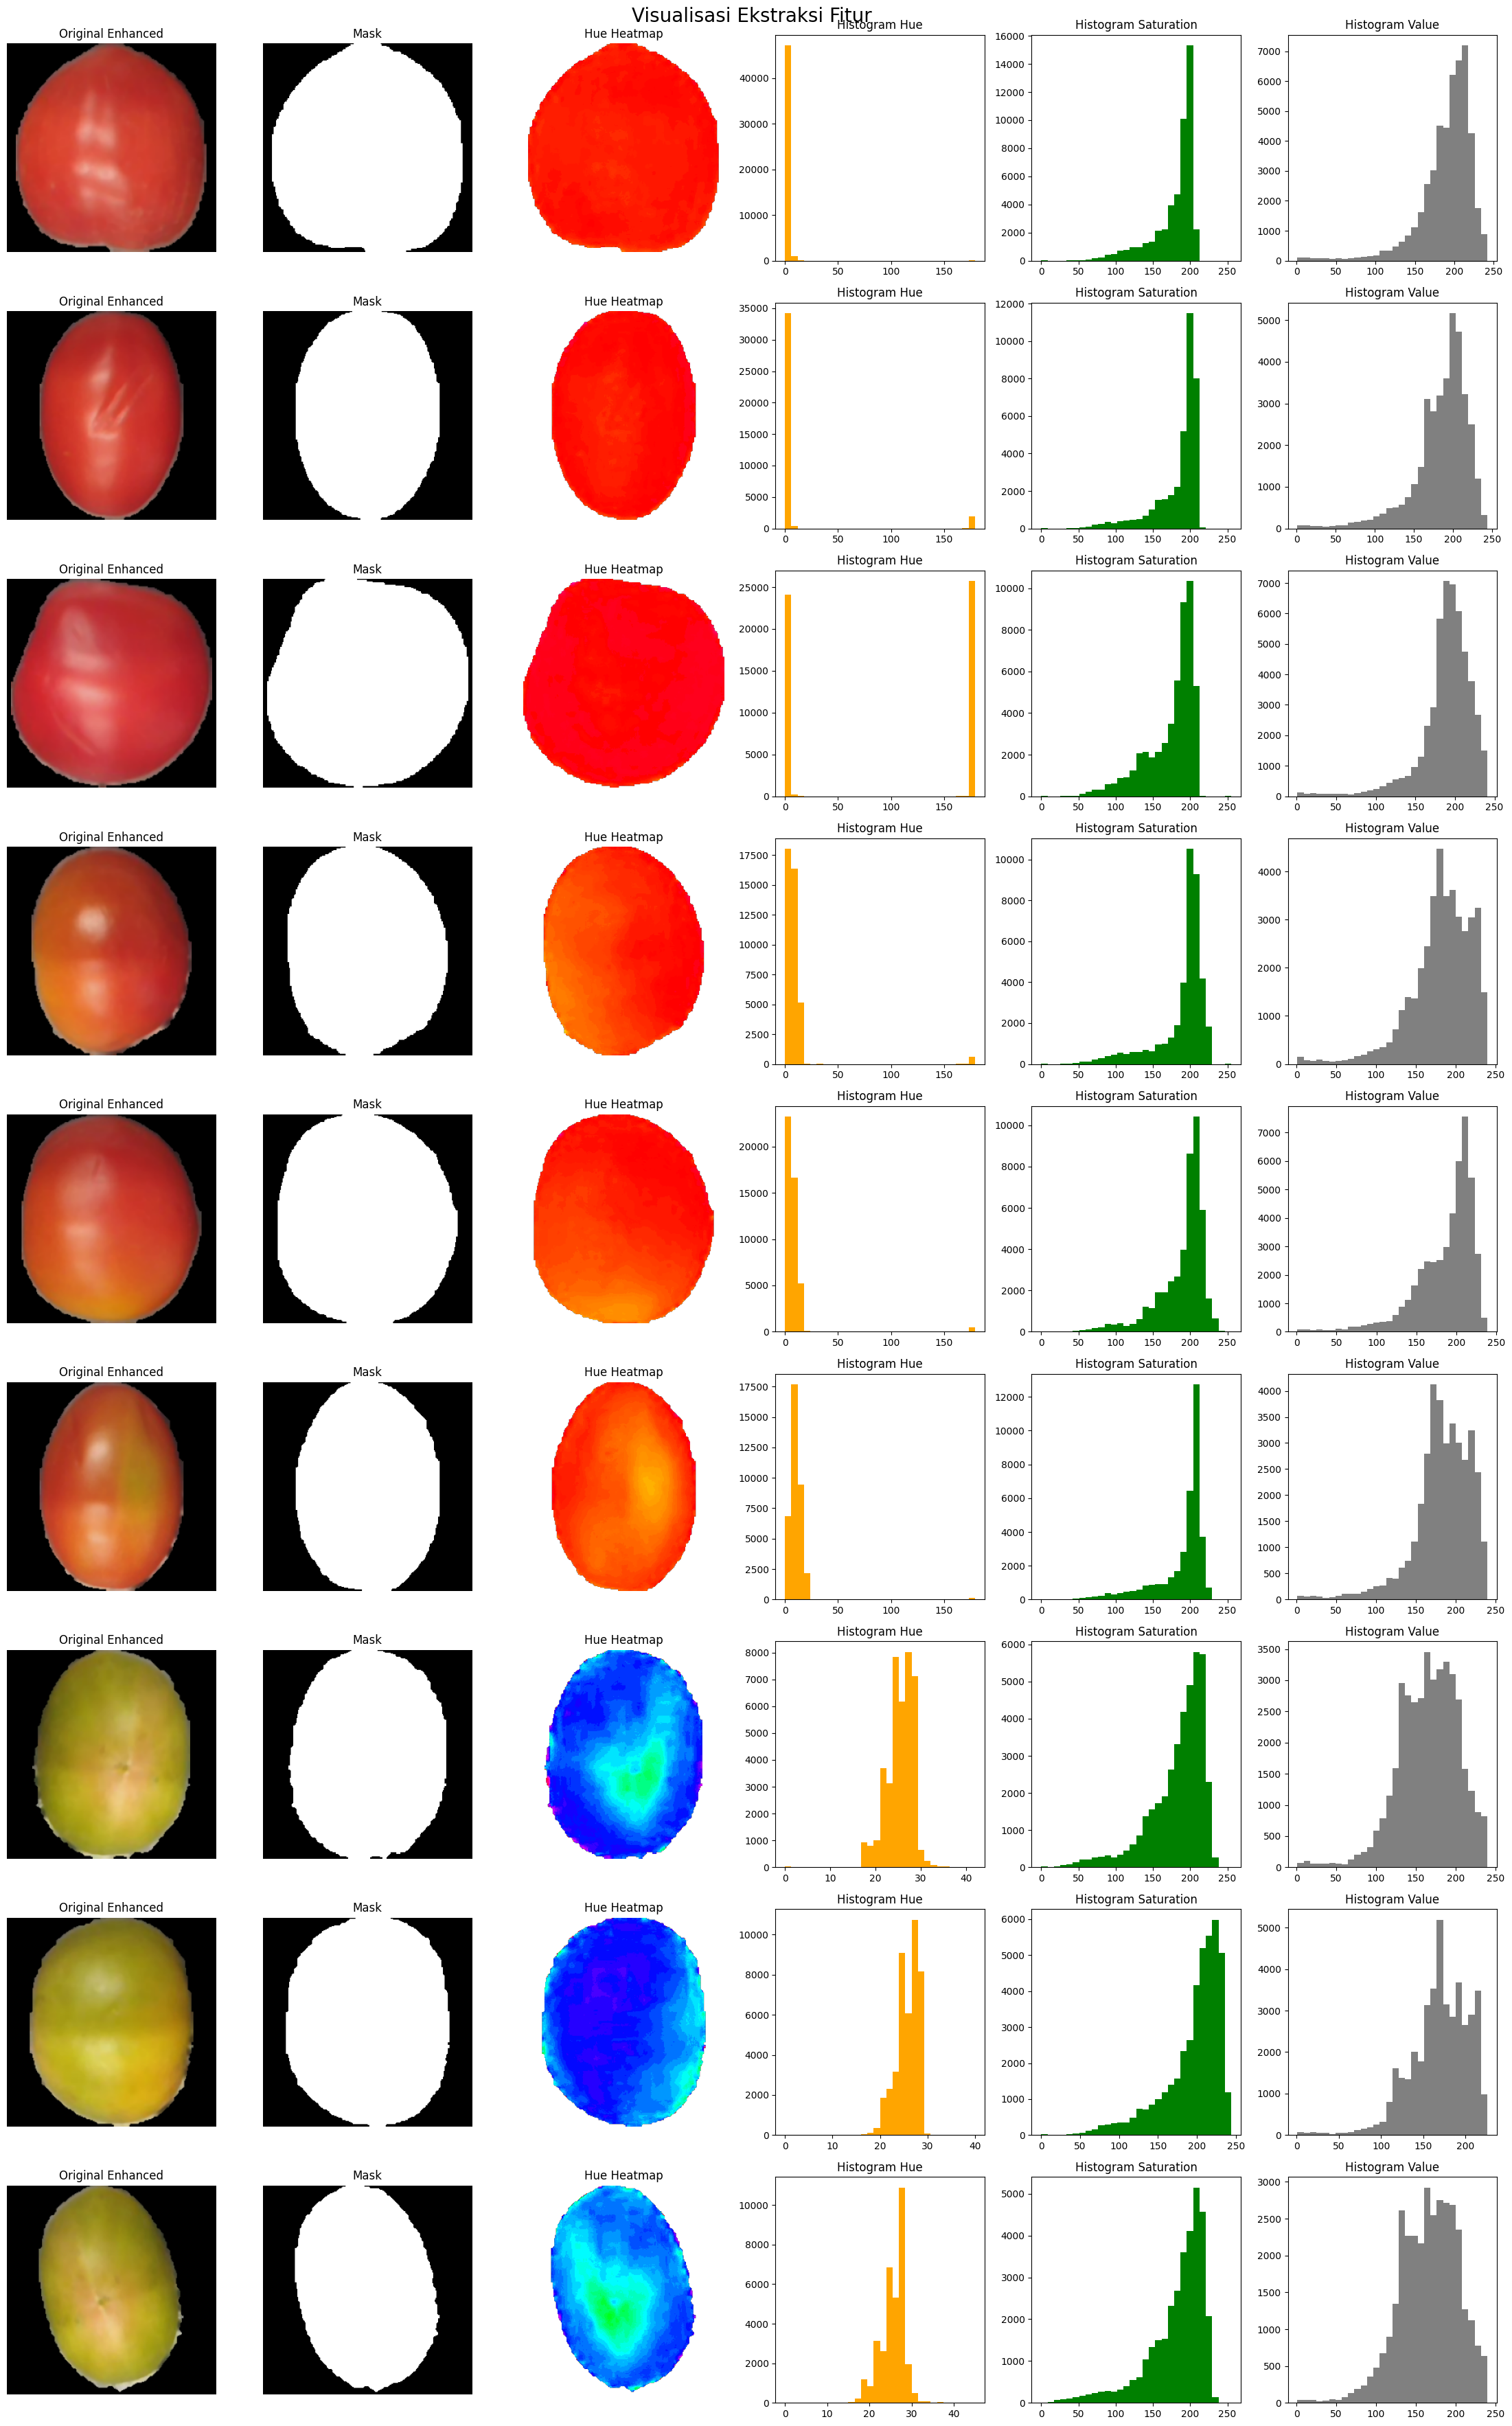


Hue Heatmap (Heatmap ini menunjukkan sebaran warna Hue pada buah. Half-ripe memiliki gradasi warna yang lebih lebar sehingga terlihat area merah bercampur kuning)
=> Warna merah berarti Hue rendah, Warna kuning–hijau berarti Hue lebih tinggi
Histogram Hue (Histogram Hue menunjukkan warna apa saja yang dominan)
=> Half-ripe: histogram dua puncak (campuran kuning–merah), Ripe: histogram terkumpul di Hue rendah, Unripe: histogram terkumpul di Hue tinggi
Histogram Saturation (Histogram Saturation memperlihatkan seberapa kuat warna tomat)
=> Unripe: saturasi tinggi, Half-ripe: saturasi sedang, Ripe: saturasi tidak setinggi unripe (lebih matte)
Histogram Value (Histogram Value menunjukkan tingkat kecerahan warna tomat, untuk membantu memastikan bahwa warna tidak terlalu dipengaruhi bayangan)
=> Tengah: cukup terang atau pas, Kanan: terlalu terang bisa saja menghilangkan detail, Kiri terlalu gelap
Mask (Mask menunjukkan area tomat yang terdeteksi)


In [ ]:
# ------------------------------------------
# VISUALISASI: 3 GAMBAR PERTAMA PER LABEL
# ------------------------------------------

paths_vis = []
for tomato in ["ripe","half-ripe","unripe"]:
    folder = f"{DATASET_ENH}/{tomato}"
    imgs = sorted(glob.glob(f"{folder}/*.png"))
    paths_vis += imgs[:3]

num_images = len(paths_vis)
fig, axes = plt.subplots(num_images, 6, figsize=(22, 4 * num_images))
fig.suptitle("Visualisasi Ekstraksi Fitur\n", fontsize=20)

if num_images == 1:
    axes = axes.reshape(1, 6)

current_row = 0

for tomato in ["ripe","half-ripe","unripe"]:
    for i in range(min(3, len(all_images_rgb[tomato]))):
        img_rgb = all_images_rgb[tomato][i]
        img_hsv = all_images_hsv[tomato][i]
        mask_bin = all_masks[tomato][i]

        ax_row = axes[current_row]

        # --- 1. Original ---
        ax_row[0].imshow(img_rgb)
        ax_row[0].set_title("Original Enhanced")
        ax_row[0].axis("off")

        # --- 2. Mask ---
        ax_row[1].imshow(mask_bin, cmap="gray")
        ax_row[1].set_title("Mask")
        ax_row[1].axis("off")

        # --- 3. Hue Heatmap ---
        Hn = (img_hsv[:,:,0].astype(np.float32)*2)/360.0
        heat = np.full_like(Hn, np.nan)
        heat[mask_bin] = Hn[mask_bin]
        ax_row[2].imshow(heat, cmap="hsv")
        ax_row[2].set_title("Hue Heatmap")
        ax_row[2].axis("off")

        # --- 4. Histogram Hue ---
        ax_row[3].hist(img_hsv[:,:,0][mask_bin], bins=30, color="orange")
        ax_row[3].set_title("Histogram Hue")

        # --- 5. Histogram Saturation ---
        ax_row[4].hist(img_hsv[:,:,1][mask_bin], bins=30, color="green")
        ax_row[4].set_title("Histogram Saturation")

        # --- 6. Histogram Value ---
        ax_row[5].hist(img_hsv[:,:,2][mask_bin], bins=30, color="gray")
        ax_row[5].set_title("Histogram Value")

        current_row += 1

plt.tight_layout()
plt.show()

print('\nHue Heatmap (Heatmap ini menunjukkan sebaran warna Hue pada buah. Half-ripe memiliki gradasi warna yang lebih lebar sehingga terlihat area merah bercampur kuning)')
print('=> Warna merah berarti Hue rendah, Warna kuning–hijau berarti Hue lebih tinggi')
print('Histogram Hue (Histogram Hue menunjukkan warna apa saja yang dominan)')
print('=> Half-ripe: histogram dua puncak (campuran kuning–merah), Ripe: histogram terkumpul di Hue rendah, Unripe: histogram terkumpul di Hue tinggi')
print('Histogram Saturation (Histogram Saturation memperlihatkan seberapa kuat warna tomat)')
print('=> Unripe: saturasi tinggi, Half-ripe: saturasi sedang, Ripe: saturasi tidak setinggi unripe (lebih matte)')
print('Histogram Value (Histogram Value menunjukkan tingkat kecerahan warna tomat, untuk membantu memastikan bahwa warna tidak terlalu dipengaruhi bayangan)')
print('=> Tengah: cukup terang atau pas, Kanan: terlalu terang bisa saja menghilangkan detail, Kiri terlalu gelap')
print('Mask (Mask menunjukkan area tomat yang terdeteksi)')

## **Bagian Visualisasi (Opsional untuk presentasi)**


Explained variance PCA:
PC1: 0.7778046345178237
PC2: 0.13985985233319193
PC3: 0.0489030580509736
Total PCA2: 0.9176644868510155
Total PCA3: 0.9665675449019892


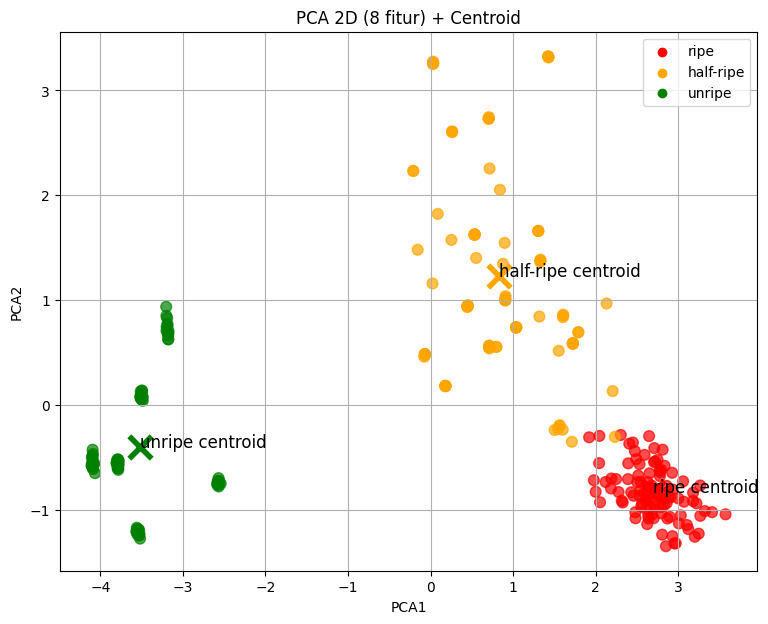

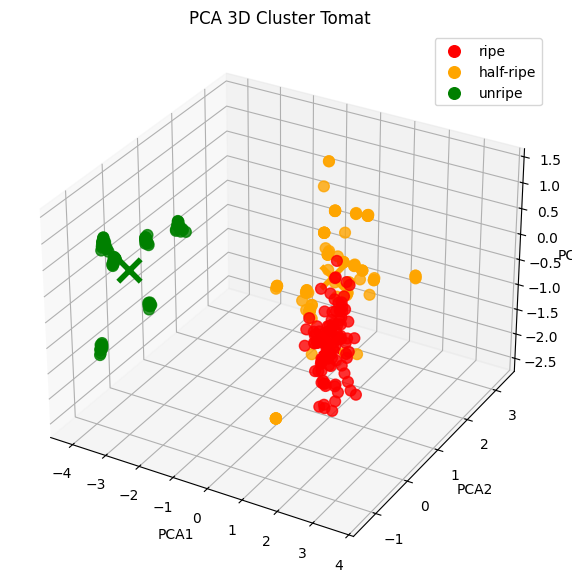

In [ ]:
# =====================   PCA   =========================
df = pd.DataFrame(all_results)

# Ambil hanya fitur numerik untuk PCA
feature_cols = [c for c in df.columns if c not in ["filename", "label", "path"]]
X = df[feature_cols].values

# ==============================================
# STANDARDISASI
# ==============================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ===========================================================
# PCA UNTUK SELURUH VISUALISASI
# (SATU PCA → agar konsisten untuk 2D, 3D, biplot, loading)
# ===========================================================
pca = PCA(n_components=3)
Xp = pca.fit_transform(X_scaled)

# Simpan nilai PCA ke DataFrame
df["PCA1"] = Xp[:,0]
df["PCA2"] = Xp[:,1]
df["PCA3"] = Xp[:,2]

# Variansi yang dijelaskan → menunjukkan seberapa besar informasi yang ditangkap PCA
expl2 = pca.explained_variance_ratio_[0:2].sum()
expl3 = pca.explained_variance_ratio_[0:3].sum()

print("\nExplained variance PCA:")
print("PC1:", pca.explained_variance_ratio_[0])
print("PC2:", pca.explained_variance_ratio_[1])
print("PC3:", pca.explained_variance_ratio_[2])
print("Total PCA2:", expl2)
print("Total PCA3:", expl3)


# ===========================================================
#               VISUALISASI PCA 2D (PC1 vs PC2)
# ===========================================================
# Warna berdasarkan kelas tomat
color_map = {
    "ripe": "red",
    "half-ripe": "orange",
    "unripe": "green"
}
df["color"] = df["label"].map(color_map)

plt.figure(figsize=(9,7))

# Scatter 2D PCA
plt.scatter(df["PCA1"], df["PCA2"], c=df["color"], s=60, alpha=0.7)

# ====================================================
# Tambahkan Centroid (Titik tengah setiap cluster)
# - Memperjelas posisi cluster
# - Membantu memahami pemisahan data
# ====================================================
centers = df.groupby("label")[["PCA1","PCA2"]].mean()

for label, row in centers.iterrows():
    # Titik 'X' menunjukkan centroid
    plt.scatter(row["PCA1"], row["PCA2"],
                c=color_map[label], s=260,
                marker="x", linewidth=4)
    plt.text(row["PCA1"], row["PCA2"],
             f"{label} centroid", fontsize=12)

# Legend manual agar warna tetap muncul
for lab, col in color_map.items():
    plt.scatter([], [], c=col, label=lab)

plt.title("PCA 2D (8 fitur) + Centroid")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.grid(True)
plt.legend()
plt.show()


# ===========================================================
#                   PCA 3D (PC1–PC2–PC3)
# ===========================================================
fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection='3d')

# Scatter 3D PCA
ax.scatter(df["PCA1"], df["PCA2"], df["PCA3"],
           c=df["color"], s=60, alpha=0.8)

# Centroid untuk 3D (tambah sumbu Z)
for label, row in centers.iterrows():
    z = df[df["label"]==label]["PCA3"].mean()
    ax.scatter(row["PCA1"], row["PCA2"], z,
               c=color_map[label], marker="x", s=260, linewidth=4)

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("PCA 3D Cluster Tomat")

# Legend manual
for lab, col in color_map.items():
    ax.scatter([], [], [], c=col, label=lab, s=70)
ax.legend()
plt.show()


=== PCA LOADING MATRIX ===
                PCA1      PCA2      PCA3
mean_cos_H  0.373531  0.091853  0.019175
mean_sin_H -0.376567  0.020213 -0.047529
circ_std_H -0.017756  0.835337 -0.478477
mean_S     -0.237634  0.500324  0.802929
mean_a      0.376941  0.033039  0.077673
norm_R      0.369766  0.106751  0.234175
rg_ratio    0.375740  0.011742  0.109644
mean_R      0.321731  0.173837 -0.170309
mean_G     -0.372000  0.014085 -0.147782



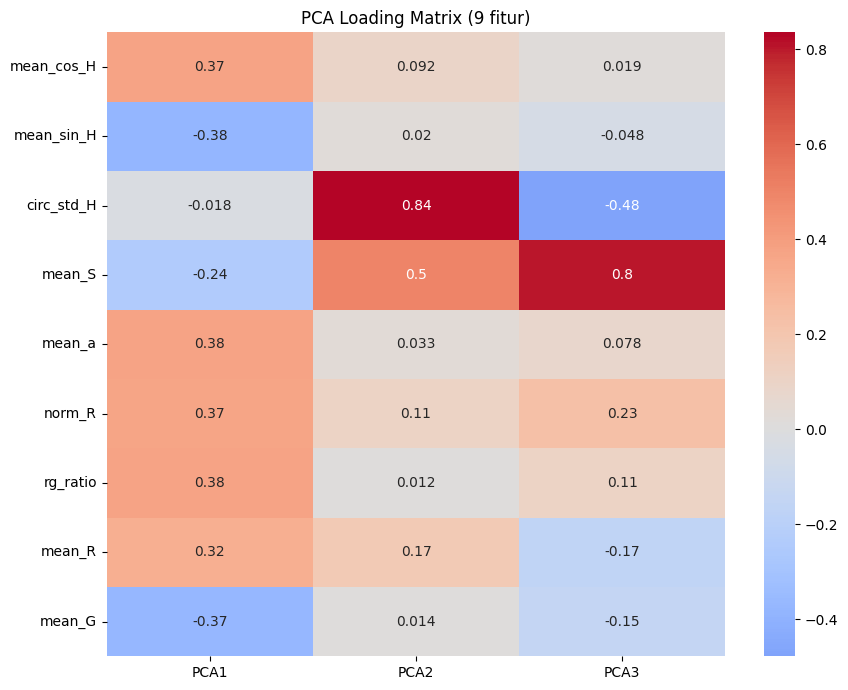

In [ ]:
# ===========================================================
#                 PCA LOADING MATRIX
# ===========================================================
# Loading matrix menunjukkan:
# - kontribusi masing–masing fitur terhadap setiap komponen PCA
# - semakin besar nilai absolut → semakin penting fitur tsb
loading = pd.DataFrame(
    pca.components_.T,
    columns=["PCA1","PCA2","PCA3"],
    index=feature_cols
)

print("\n=== PCA LOADING MATRIX ===")
print(loading)
print()

plt.figure(figsize=(9,7))
sns.heatmap(loading, annot=True, cmap="coolwarm", center=0)
plt.title("PCA Loading Matrix (9 fitur)")
plt.tight_layout()
plt.show()

# **Model KNN**

## **1. Import Library**

In [ ]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("✅ Library berhasil diimport")

✅ Library berhasil diimport


## **2. Persiapan Data**

In [ ]:
# Pastikan DataFrame 'df' sudah ada dari cell ekstraksi fitur sebelumnya
# Jika belum, coba load dari CSV

if 'df' not in globals():
    possible_csv = 'features_extracted.csv'
    if os.path.exists(possible_csv):
        print(f'📂 Loading features dari {possible_csv}')
        df = pd.read_csv(possible_csv)
    else:
        raise RuntimeError('❌ DataFrame `df` tidak ditemukan. Jalankan cell ekstraksi fitur terlebih dahulu!')

# Pisahkan fitur (X) dan label (y)
# Kolom yang BUKAN fitur: filename, path, label, color (dari PCA visualisasi), PCA1, PCA2, PCA3
drop_cols = [c for c in df.columns if c in ['filename', 'path', 'color', 'PCA1', 'PCA2', 'PCA3']]
feature_cols = [c for c in df.columns if c not in drop_cols + ['label']]

X = df[feature_cols].values.astype(np.float32)
y = df['label'].values

print('📊 Bentuk Dataset:', X.shape)
print('🏷️ Label Kelas:', np.unique(y))
print('📝 Jumlah fitur:', len(feature_cols))
print('📝 Nama fitur:', feature_cols)
print('✅ Data siap untuk training')

📊 Bentuk Dataset: (300, 9)
🏷️ Label Kelas: ['half-ripe' 'ripe' 'unripe']
📝 Jumlah fitur: 9
📝 Nama fitur: ['mean_cos_H', 'mean_sin_H', 'circ_std_H', 'mean_S', 'mean_a', 'norm_R', 'rg_ratio', 'mean_R', 'mean_G']
✅ Data siap untuk training


## **3. Split Data (Train & Test)**

In [ ]:
# Split data menjadi 80% training dan 20% testing
# Stratified split memastikan proporsi setiap kelas tetap sama di train dan test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print('📊 Data Training:', X_train.shape)
print('📊 Data Testing:', X_test.shape)
print('✅ Split data berhasil dengan rasio 80:20')

📊 Data Training: (240, 9)
📊 Data Testing: (60, 9)
✅ Split data berhasil dengan rasio 80:20


## **4. Standardisasi Fitur**

In [ ]:
# Standardisasi: Mengubah semua fitur agar memiliki mean=0 dan std=1
# Penting untuk KNN karena algoritma ini sensitif terhadap skala fitur

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('✅ Fitur berhasil di-standardisasi')
print('📊 Mean setelah scaling (train):', X_train_scaled.mean(axis=0).round(4))
print('📊 Std setelah scaling (train):', X_train_scaled.std(axis=0).round(4))

✅ Fitur berhasil di-standardisasi
📊 Mean setelah scaling (train): [ 0.  0.  0. -0. -0. -0. -0. -0. -0.]
📊 Std setelah scaling (train): [1. 1. 1. 1. 1. 1. 1. 1. 1.]


## **5. Reduksi Dimensi dengan PCA (95% Variance)**

In [ ]:
# PCA: Mengurangi dimensi fitur sambil mempertahankan 95% informasi
# Ini mempercepat training dan mengurangi overfitting

X_train_pca = X_train_scaled
X_test_pca = X_test_scaled

print('📊 Dimensi fitur awal:', X_train_scaled.shape[1])
print('📊 Dimensi fitur setelah PCA:', X_train_pca.shape[1])
print('📈 Variance yang dipertahankan:', f'{pca.explained_variance_ratio_.sum():.2%}')
print('✅ Reduksi dimensi berhasil')

📊 Dimensi fitur awal: 9
📊 Dimensi fitur setelah PCA: 9
📈 Variance yang dipertahankan: 96.66%
✅ Reduksi dimensi berhasil


## **6. Hyperparameter Tuning dengan GridSearchCV**

In [ ]:
# GridSearchCV: Mencari kombinasi parameter terbaik secara otomatis
# Parameter yang dicoba:
# - n_neighbors: jumlah tetangga terdekat (K)
# - weights: bobot berdasarkan jarak atau uniform
# - metric: metrik jarak (minkowski = euclidean untuk p=2)

param_grid = {
    'n_neighbors': [1, 3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['minkowski']
}

knn = KNeighborsClassifier()
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('🔍 Memulai pencarian parameter terbaik...')
print(f'📊 Total kombinasi yang akan dicoba: {len(param_grid["n_neighbors"]) * len(param_grid["weights"])}')

grid_search = GridSearchCV(
    knn,
    param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_pca, y_train)

print('\n✅ Pencarian selesai!')
print('🎯 Parameter terbaik:', grid_search.best_params_)
print(f'📈 Akurasi CV terbaik: {grid_search.best_score_:.4f}')

🔍 Memulai pencarian parameter terbaik...
📊 Total kombinasi yang akan dicoba: 16
Fitting 5 folds for each of 16 candidates, totalling 80 fits

✅ Pencarian selesai!
🎯 Parameter terbaik: {'metric': 'minkowski', 'n_neighbors': 7, 'weights': 'distance'}
📈 Akurasi CV terbaik: 0.9958


## **7. Evaluasi Model pada Data Test**

In [ ]:
# Gunakan model terbaik untuk prediksi pada data test
best_knn = grid_search.best_estimator_
y_pred = best_knn.predict(X_test_pca)

# Hitung akurasi
test_accuracy = accuracy_score(y_test, y_pred)

print('='*50)
print('📊 HASIL EVALUASI MODEL KNN')
print('='*50)
print(f'🎯 Akurasi Test: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)')
print('\n📋 Classification Report:')
print(classification_report(y_test, y_pred))
print('='*50)

📊 HASIL EVALUASI MODEL KNN
🎯 Akurasi Test: 0.9833 (98.33%)

📋 Classification Report:
              precision    recall  f1-score   support

   half-ripe       1.00      0.95      0.97        20
        ripe       0.95      1.00      0.98        20
      unripe       1.00      1.00      1.00        20

    accuracy                           0.98        60
   macro avg       0.98      0.98      0.98        60
weighted avg       0.98      0.98      0.98        60



## **8. Visualisasi Confusion Matrix**

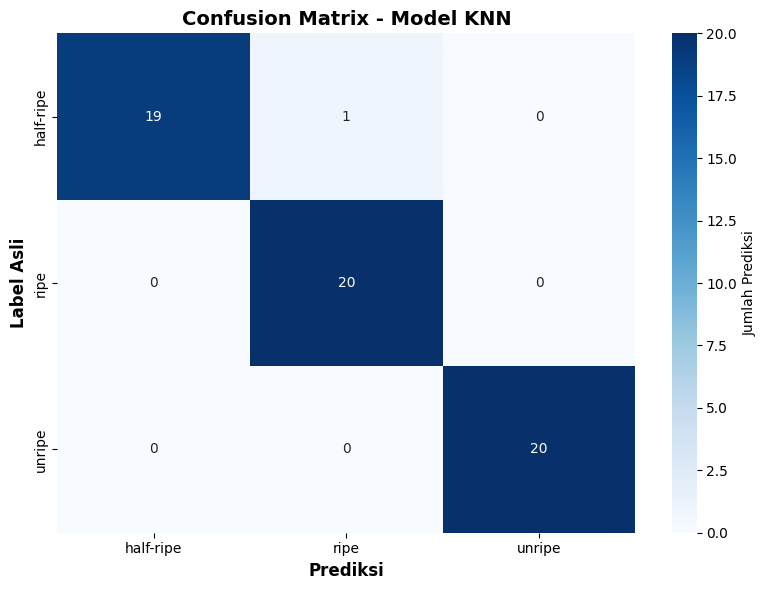

💡 Interpretasi Confusion Matrix:
   - Diagonal (atas-kiri ke bawah-kanan) = Prediksi BENAR
   - Off-diagonal = Prediksi SALAH (misklasifikasi)


In [ ]:
# Confusion Matrix menunjukkan detail prediksi benar dan salah per kelas
cm = confusion_matrix(y_test, y_pred, labels=np.unique(y))

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y),
            yticklabels=np.unique(y),
            cbar_kws={'label': 'Jumlah Prediksi'})
plt.xlabel('Prediksi', fontsize=12, fontweight='bold')
plt.ylabel('Label Asli', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix - Model KNN', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('💡 Interpretasi Confusion Matrix:')
print('   - Diagonal (atas-kiri ke bawah-kanan) = Prediksi BENAR')
print('   - Off-diagonal = Prediksi SALAH (misklasifikasi)')

## **9. Analisis Performa untuk Setiap Nilai K**

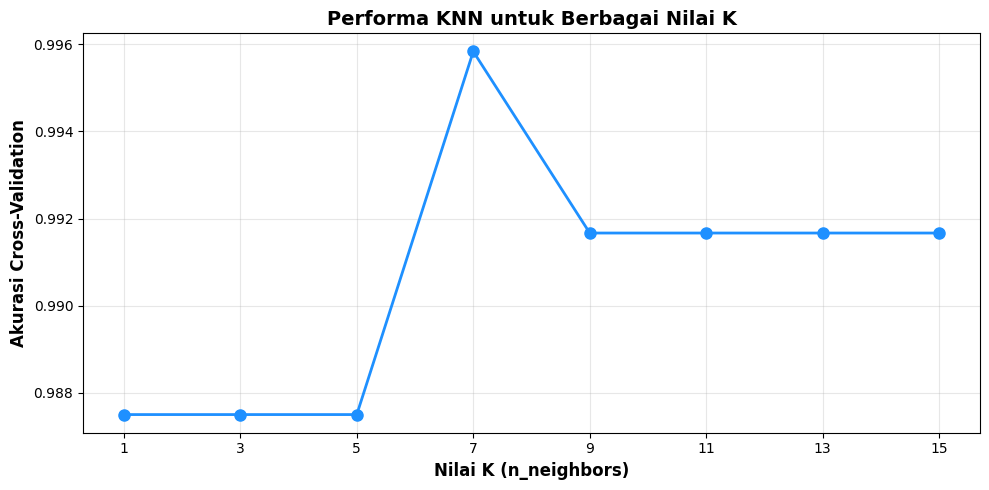

💡 Interpretasi Grafik:
   - K terbaik: 7
   - K terlalu kecil → Overfitting (terlalu sensitif terhadap noise)
   - K terlalu besar → Underfitting (terlalu general)


In [ ]:
# Visualisasi bagaimana performa berubah untuk setiap nilai K
cv_results = pd.DataFrame(grid_search.cv_results_)

# Ambil akurasi terbaik untuk setiap nilai K
scores_by_k = cv_results.groupby('param_n_neighbors')['mean_test_score'].max()

plt.figure(figsize=(10, 5))
scores_by_k.plot(kind='line', marker='o', color='dodgerblue', linewidth=2, markersize=8)
plt.xlabel('Nilai K (n_neighbors)', fontsize=12, fontweight='bold')
plt.ylabel('Akurasi Cross-Validation', fontsize=12, fontweight='bold')
plt.title('Performa KNN untuk Berbagai Nilai K', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(scores_by_k.index)
plt.tight_layout()
plt.show()

print('💡 Interpretasi Grafik:')
print(f'   - K terbaik: {grid_search.best_params_["n_neighbors"]}')
print('   - K terlalu kecil → Overfitting (terlalu sensitif terhadap noise)')
print('   - K terlalu besar → Underfitting (terlalu general)')

# Model SVM

## Import Library

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import pickle

print("\n=== MEMULAI TRAINING SVM ===")


=== MEMULAI TRAINING SVM ===


## 1. Dataset

In [ ]:
# ============================================
# 1. Dataset
# ============================================
X = df[feature_cols].values       # 9 fitur
y = df["label"].values            # label tomato (ripe, half-ripe, unripe)

print("Dimensi awal fitur:", X.shape)
print("Jumlah data :", len(y))


Dimensi awal fitur: (300, 9)
Jumlah data : 300


## Train-Test Split

In [ ]:
# ============================================
# 2. Train-Test Split
# ============================================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Standarisasi

In [ ]:
# ============================================
# 3. Standardisasi
# ============================================
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

## PCA (khusus SVM)

In [ ]:
# ============================================
# 4. PCA (khusus SVM)
# ============================================
from sklearn.decomposition import PCA

# pca = PCA(n_components=0.95, random_state=42)
X_train_final = X_train_scaled
X_test_final  = X_test_scaled

print("Jumlah komponen PCA untuk SVM:", X_train_final.shape[1])

Jumlah komponen PCA untuk SVM: 9


## Training SVM

In [ ]:
# ============================================
# 5. Training SVM + Grid Search
# ============================================
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [1, 10, 100],
    "kernel": ["rbf", "linear"],
    "gamma": ["scale", "auto"],
    "probability": [True]
}

grid = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    n_jobs=-1,
    scoring="accuracy",
    verbose=1
)

grid.fit(X_train_pca, y_train)

best_svm = grid.best_estimator_

print("Best Params SVM:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Params SVM: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf', 'probability': True}
Best CV Accuracy: 0.9916666666666666


## Evaluasi SVM


=== Classification Report SVM ===
              precision    recall  f1-score   support

   half-ripe       1.00      0.95      0.97        20
        ripe       0.95      1.00      0.98        20
      unripe       1.00      1.00      1.00        20

    accuracy                           0.98        60
   macro avg       0.98      0.98      0.98        60
weighted avg       0.98      0.98      0.98        60

Akurasi Testing SVM: 0.9833333333333333


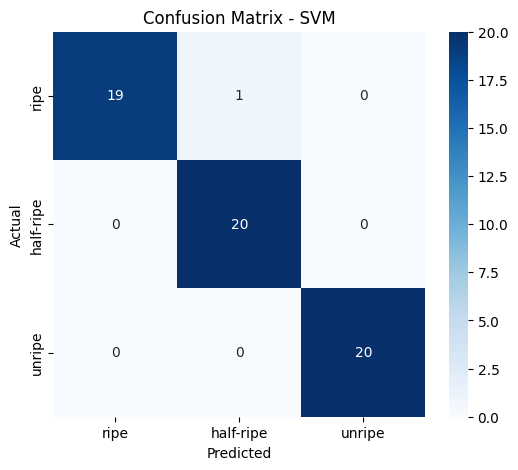

In [ ]:
# ============================================
# 6. Evaluasi SVM
# ============================================
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = best_svm.predict(X_test_pca)

print("\n=== Classification Report SVM ===")
print(classification_report(y_test, y_pred))

print("Akurasi Testing SVM:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["ripe","half-ripe","unripe"],
            yticklabels=["ripe","half-ripe","unripe"])
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

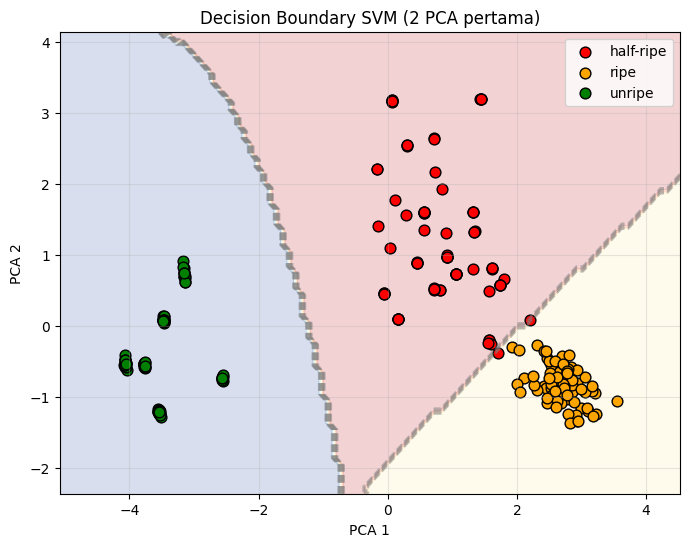

In [ ]:
# from sklearn.preprocessing import LabelEncoder

# # Encode label ke angka
# le = LabelEncoder()
# y_train_enc = le.fit_transform(y_train)  # y_train menjadi 0,1,2
# y_test_enc  = le.transform(y_test)

# # Train ulang SVM 2D dengan label asli tetap untuk interpretasi
# svm_2d.fit(X_train_2d, y_train_enc)

# # Buat meshgrid
# Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])
# Z = Z.reshape(xx.shape)

# # Plot
# plt.figure(figsize=(8,6))
# plt.contourf(xx, yy, Z, alpha=0.2, cmap=plt.cm.RdYlBu)
# plt.contour(xx, yy, Z, colors='gray', linestyles='dashed', alpha=0.5)

# # Plot titik data
# colors = ["yellow", "red", "green"]
# for i, color in enumerate(colors):
#     plt.scatter(X_train_2d[y_train_enc==i, 0],
#                 X_train_2d[y_train_enc==i, 1],
#                 c=color, label=le.inverse_transform([i])[0], edgecolor='k', s=60)

# plt.xlabel("PCA 1")
# plt.ylabel("PCA 2")
# plt.title("Decision Boundary SVM (2 PCA pertama)")
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.show()

# ======

from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA

# Apply PCA for 2D visualization
pca_2d = PCA(n_components=2, random_state=42)
X_train_2d = pca_2d.fit_transform(X_train_scaled)
X_test_2d = pca_2d.transform(X_test_scaled)

# Initialize a new SVM for 2D decision boundary plotting (using the best parameters found earlier)
svm_2d = SVC(C=grid.best_params_['C'], kernel=grid.best_params_['kernel'], gamma=grid.best_params_['gamma'], probability=True, random_state=42)

# Encode label ke angka
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)  # y_train menjadi 0,1,2
y_test_enc  = le.transform(y_test)

# Train ulang SVM 2D dengan label asli tetap untuk interpretasi
svm_2d.fit(X_train_2d, y_train_enc)

# Buat meshgrid untuk plotting decision boundary
x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

# Predict on meshgrid points
Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.2, cmap=plt.cm.RdYlBu)
plt.contour(xx, yy, Z, colors='gray', linestyles='dashed', alpha=0.5)

# Plot titik data
colors = ["red", "orange", "green"]
# Make sure the order matches the encoded labels: half-ripe, ripe, unripe
# le.classes_ should be ['half-ripe', 'ripe', 'unripe'] based on previous output
class_names = le.classes_

for i, class_name in enumerate(class_names):
    plt.scatter(X_train_2d[y_train_enc==i, 0],
                X_train_2d[y_train_enc==i, 1],
                c=colors[i], label=class_name, edgecolor='k', s=60)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Decision Boundary SVM (2 PCA pertama)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# TESTING

Saving unripe (98).jpg to unripe (98).jpg


/tmp/ipython-input-1900414836.py:182: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


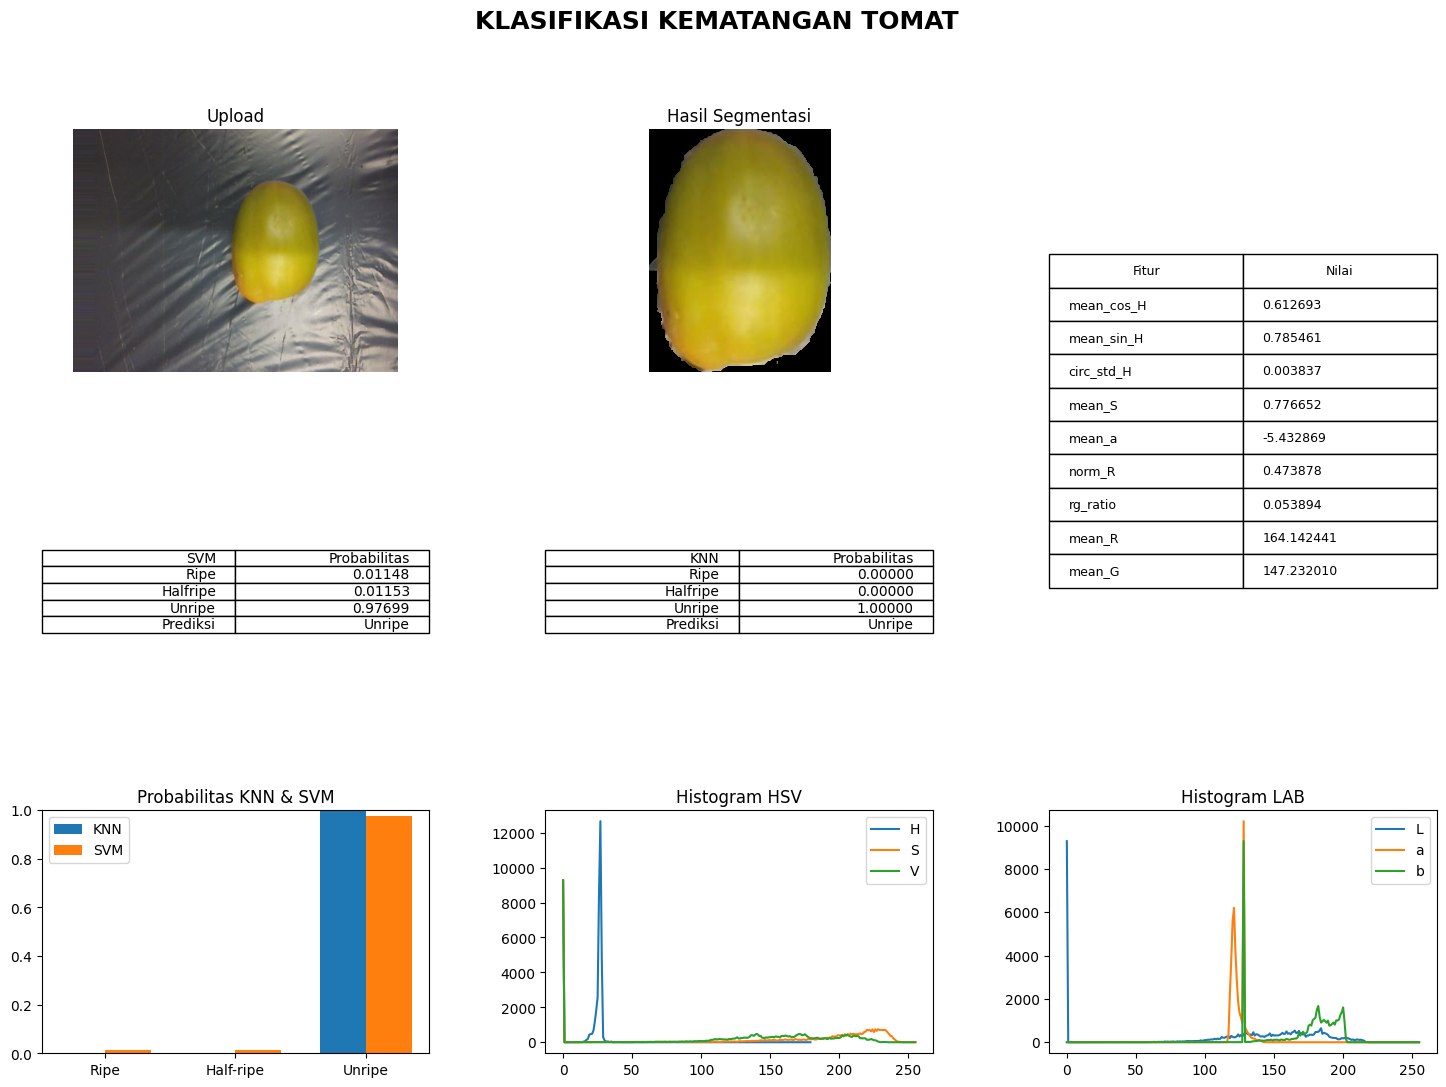


📊 RINGKASAN HASIL PREDIKSI
KNN  → Unripe
SVM  → Unripe


In [ ]:
# Prediksi Tomat Baru - Output Final
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from google.colab import files

# ========================================
# 1. UPLOAD GAMBAR
# ========================================
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

img_bgr = cv2.imread(file_name)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# ========================================
# 2. SEGMENTASI
# ========================================
ori, mask, seg, crop = auto_segment_grabcut(img_bgr)

if crop is None:
    raise ValueError("❌ Segmentasi gagal! Tomat tidak terdeteksi.")

# ========================================
# 3. EKSTRAKSI FITUR
# ========================================
features_dict, img_rgb_feat, img_hsv_feat, mask_bin_feat = extract_features(crop)

fitur_array = np.array([[
    features_dict['mean_cos_H'],
    features_dict['mean_sin_H'],
    features_dict['circ_std_H'],
    features_dict['mean_S'],
    features_dict['mean_a'],
    features_dict['norm_R'],
    features_dict['rg_ratio'],
    features_dict['mean_R'],
    features_dict['mean_G']
]])

# ========================================
# 4. PREPROCESSING (SCALING SAJA — TANPA PCA)
# ========================================
fitur_scaled = scaler.transform(fitur_array)

# ========================================
# 5. PREDIKSI KNN & SVM (TANPA PCA)
# ========================================
# -------- KNN ---------
pred_knn = best_knn.predict(fitur_scaled)[0]
proba_knn_raw = best_knn.predict_proba(fitur_scaled)[0]

classes_knn = best_knn.classes_
proba_knn = {cls: proba_knn_raw[i] for i, cls in enumerate(classes_knn)}

# -------- SVM ---------
pred_svm = best_svm.predict(fitur_scaled)[0]

try:
    proba_svm_raw = best_svm.predict_proba(fitur_scaled)[0]
    classes_svm = best_svm.classes_
    proba_svm = {cls: proba_svm_raw[i] for i, cls in enumerate(classes_svm)}
except:
    scores = best_svm.decision_function(fitur_scaled)[0]
    exp = np.exp(scores - np.max(scores))
    softmax = exp / exp.sum()
    classes_svm = best_svm.classes_
    proba_svm = {cls: softmax[i] for i, cls in enumerate(classes_svm)}

# Untuk tampilan
label_order = ['ripe', 'half-ripe', 'unripe']
label_map_display = {'ripe': 'Ripe', 'half-ripe': 'Halfripe', 'unripe': 'Unripe'}

pred_knn_display = label_map_display[pred_knn]
pred_svm_display = label_map_display[pred_svm]


# ================================================================
# 8. VISUALISASI LENGKAP
# ================================================================
fig = plt.figure(figsize=(18, 12))
gs = GridSpec(3, 3, figure=fig, hspace=0.4, wspace=0.3)

# --- Gambar asli ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.imshow(img_rgb)
ax1.set_title("Upload")
ax1.axis("off")

# --- Hasil segmentasi ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
ax2.set_title("Hasil Segmentasi")
ax2.axis("off")

# --- Tabel fitur ---
ax_table = fig.add_subplot(gs[0:2, 2])
ax_table.axis("off")
table_data = [[k, f"{v:.6f}"] for k, v in features_dict.items()]
tbl = ax_table.table(cellText=table_data, colLabels=["Fitur", "Nilai"],
                       loc="center", cellLoc="left")
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 2)

# ==============================
# SVM TABLE
# ==============================
ax_svm = fig.add_subplot(gs[1, 0])
ax_svm.axis("off")

svm_rows = [["SVM", "Probabilitas"]]
for lbl in label_order:
    val = proba_svm.get(lbl, 0)
    svm_rows.append([label_map_display[lbl], f"{val:.5f}"])
svm_rows.append(["Prediksi", pred_svm_display])

ax_svm.table(cellText=svm_rows, loc="center")

# ==============================
# KNN TABLE
# ==============================
ax_knn = fig.add_subplot(gs[1, 1])
ax_knn.axis("off")

knn_rows = [["KNN", "Probabilitas"]]
for lbl in label_order:
    val = proba_knn.get(lbl, 0)
    knn_rows.append([label_map_display[lbl], f"{val:.5f}"])
knn_rows.append(["Prediksi", pred_knn_display])

ax_knn.table(cellText=knn_rows, loc="center")


# ==============================
# HISTOGRAMS
# ==============================
crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
crop_hsv = cv2.cvtColor(crop, cv2.COLOR_BGR2HSV)
crop_lab = cv2.cvtColor(crop, cv2.COLOR_BGR2LAB)

# RGB Histogram
# PROBABILITY BAR CHART KNN & SVM
ax_prob = fig.add_subplot(gs[2, 0])
labels = ['Ripe', 'Half-ripe', 'Unripe']

prob_knn_vals = [proba_knn['ripe'], proba_knn['half-ripe'], proba_knn['unripe']]
prob_svm_vals = [proba_svm['ripe'], proba_svm['half-ripe'], proba_svm['unripe']]

x = np.arange(len(labels))
bar_width = 0.35

ax_prob.bar(x - bar_width/2, prob_knn_vals, width=bar_width, label='KNN')
ax_prob.bar(x + bar_width/2, prob_svm_vals, width=bar_width, label='SVM')

ax_prob.set_xticks(x)
ax_prob.set_xticklabels(labels)
ax_prob.set_ylim(0, 1)
ax_prob.set_title("Probabilitas KNN & SVM")
ax_prob.legend()



# # HSV Histogram
ax_hist_hsv = fig.add_subplot(gs[2, 1])
ax_hist_hsv.plot(cv2.calcHist([crop_hsv], [0], None, [180], [0, 180]), label="H")
ax_hist_hsv.plot(cv2.calcHist([crop_hsv], [1], None, [256], [0, 256]), label="S")
ax_hist_hsv.plot(cv2.calcHist([crop_hsv], [2], None, [256], [0, 256]), label="V")
ax_hist_hsv.set_title("Histogram HSV")
ax_hist_hsv.legend()

# # LAB Histogram
ax_hist_lab = fig.add_subplot(gs[2, 2])
ax_hist_lab.plot(cv2.calcHist([crop_lab], [0], None, [256], [0, 256]), label="L")
ax_hist_lab.plot(cv2.calcHist([crop_lab], [1], None, [256], [0, 256]), label="a")
ax_hist_lab.plot(cv2.calcHist([crop_lab], [2], None, [256], [0, 256]), label="b")
ax_hist_lab.set_title("Histogram LAB")
ax_hist_lab.legend()

fig.suptitle("KLASIFIKASI KEMATANGAN TOMAT", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()


# ================================================================
# 9. RINGKASAN
# ================================================================
print("\n====================================================")
print("📊 RINGKASAN HASIL PREDIKSI")
print("====================================================")
print(f"KNN  → {pred_knn_display}")
print(f"SVM  → {pred_svm_display}")
print("====================================================")

# pembuatan file model

In [ ]:
import pickle

# Simpan model SVM
with open('svm_model.pkl', 'wb') as f:
    pickle.dump(best_svm, f)

# Simpan model KNN
with open('knn_model.pkl', 'wb') as f:
    pickle.dump(best_knn, f)

# Simpan scaler dan PCA
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('pca.pkl', 'wb') as f:
    pickle.dump(pca, f)

print("✅ Semua model dan preprocessing berhasil disimpan!")